## Mount Google Drive

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import joblib

## Load Processed Dataset

In [20]:
data_path = "/content/drive/MyDrive/Fatigue-Life-ML/data/processed/fatigue_dataset_clean.csv"

df = pd.read_csv(data_path)

df.head()

,base_yield_strength,base_ultimate_strength,welding_joint,welding_method,welding_voltage,welding_current,welding_speed,fatigue_specimen_type,fatigue_specimen_thickness,residual_stress,stress_concentration,load_ratio,stress_range,fatigue_life,stress_amplitude,mean_stress,normalized_stress,stress_strength_ratio,log_fatigue_life
0,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,185.0,2000000.0,92.5,101.75,0.521127,0.321739,6.301030
1,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,220.0,2000000.0,110.0,121.00,0.619718,0.382609,6.301030
2,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,36400.0,44.5,48.95,0.100000,0.086829,4.561101
3,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,31363.0,44.5,48.95,0.100000,0.086829,4.496418
4,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,23461.0,44.5,48.95,0.100000,0.086829,4.370347


## Prepare Features and Target

In [21]:
X = df.drop(["fatigue_life", "log_fatigue_life"], axis=1)

y = df["log_fatigue_life"]

## Encode Categorical Variables

In [22]:
X = pd.get_dummies(X, drop_first=True)

## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Load Trained Random Forest Model

In [24]:
model_path = "/content/drive/MyDrive/Fatigue-Life-ML/models/random_forest.pkl"

rf_model = joblib.load(model_path)

## Make Predictions

In [25]:
y_pred = rf_model.predict(X_test)

## Compute Prediction Error

In [26]:
errors = y_test - y_pred

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.48911581157590994


## Estimate Prediction Uncertainty

In [27]:
error_std = np.std(errors)

print("Prediction Standard Deviation:", error_std)

Prediction Standard Deviation: 0.4891091731340375


## Compute Prediction Interval

In [28]:
lower_bound = y_pred - 1.96 * error_std
upper_bound = y_pred + 1.96 * error_std

## Prediction vs Actual Plot

### The scatter plot compares the actual log fatigue life values with the predicted values from the machine learning model. The red diagonal line represents the ideal case where predictions exactly match the actual values.

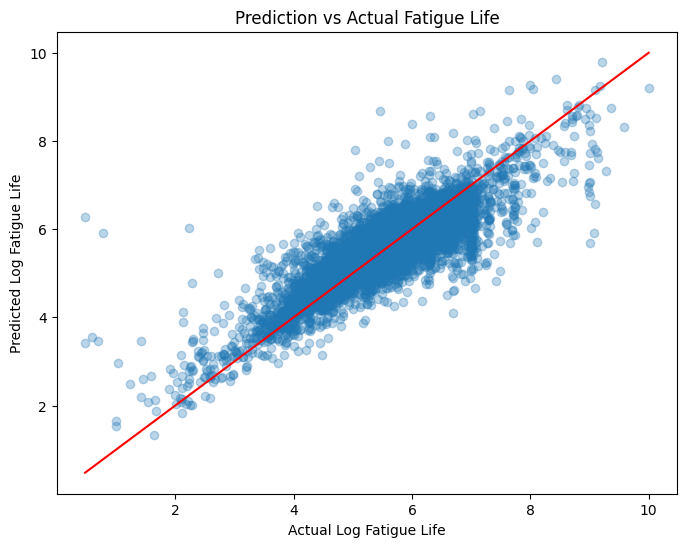

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Log Fatigue Life")
plt.ylabel("Predicted Log Fatigue Life")

plt.title("Prediction vs Actual Fatigue Life")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/prediction_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Most points lie close to the diagonal line, indicating that the model captures the general trend between input features and fatigue life. However, some deviations from the line are visible, showing that prediction errors exist for certain samples.

## Error Distribution

### The histogram shows the distribution of prediction errors, which are calculated as the difference between the actual fatigue life values and the model’s predicted values.

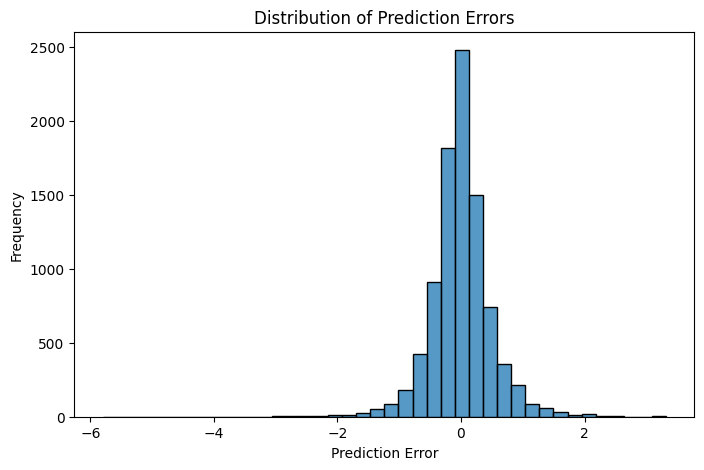

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(errors, bins=40)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Distribution of Prediction Errors")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Most prediction errors are concentrated around zero, indicating that many predictions are close to the actual values. However, the distribution also shows some larger positive and negative errors, reflecting variability in the model’s predictions.

## Error Statistics

### Error statistics summarize the mean prediction error and the standard deviation of the errors obtained from the model predictions.

In [31]:
print("Mean Prediction Error:", np.mean(errors))
print("Error Standard Deviation:", np.std(errors))

Mean Prediction Error: -0.0025483111463086047
Error Standard Deviation: 0.4891091731340375


### The mean prediction error is close to zero, indicating that the model does not show a strong systematic bias toward over- or under-prediction. The standard deviation reflects the spread of prediction errors, showing the variability present in the model’s predictions.

## Prediction Interval Visualization

## The plot shows the predicted fatigue life values with an uncertainty interval, where the shaded region represents the estimated prediction interval around the model predictions.

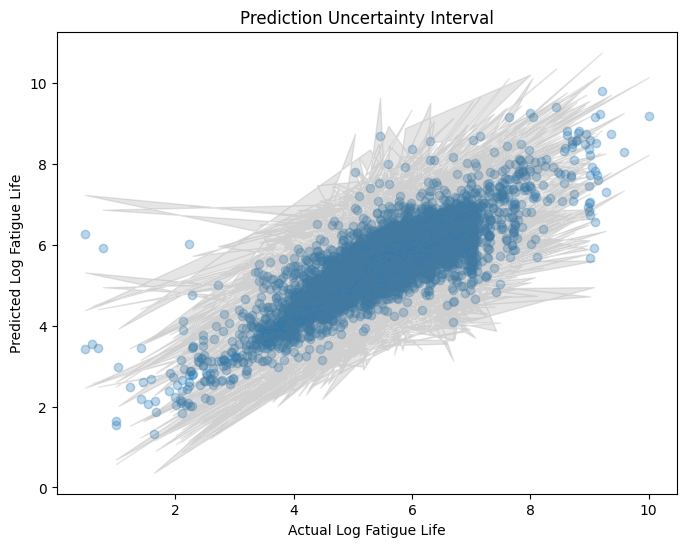

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.fill_between(
    y_test,
    lower_bound,
    upper_bound,
    color="gray",
    alpha=0.2
)

plt.xlabel("Actual Log Fatigue Life")
plt.ylabel("Predicted Log Fatigue Life")

plt.title("Prediction Uncertainty Interval")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/prediction_uncertainty_interval.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The shaded interval indicates the range within which the true fatigue life values may fall based on the model’s prediction uncertainty. The spread of the shaded region reflects the variability in prediction errors across the dataset.